# 03 - Augmentation, Balancing, Transfer Learning & Training
**Diabetic Retinopathy Stage Detection**

Covers rubric criteria 3 (augmentation & balancing), 4 (CNN architecture & transfer
learning) and 5 (training strategy). Every experiment is logged to
`outputs/runs/experiments.csv` so the report tables are generated, not typed.

1. Retina-safe augmentation - one image, eight augmented views.
2. Class imbalance - partial oversampling + class-weighted loss, before/after distribution.
3. Baseline CNN from scratch (why we need transfer learning).
4. Ablation: no balancing vs weights vs oversample + weights.
5. Two-stage transfer learning: EfficientNet-B0 and ResNet50.
6. Hyper-parameter sweep (learning rate, dropout).
7. Comparison table + training curves.

All logic lives in `src/augment.py`, `src/model.py`, `src/train.py`; this notebook only calls it.

In [1]:
# --- Environment bootstrap: works on Kaggle, Ubuntu GPU box and Windows ----
import os, sys, subprocess
from pathlib import Path

REPO = "https://github.com/pradeesha999/dr-stage-detection-v2.git"
if Path("/kaggle/working").exists():
    dst = Path("/kaggle/working/dr_project")
    if not dst.exists():
        try:   # private repo: store a GitHub token as Kaggle secret GITHUB_TOKEN
            from kaggle_secrets import UserSecretsClient
            url = REPO.replace("https://", f"https://{UserSecretsClient().get_secret('GITHUB_TOKEN')}@")
        except Exception:
            url = REPO                      # works as-is if the repo is public
        subprocess.run(["git", "clone", "-q", url, str(dst)], check=True)
    os.chdir(dst / "notebooks")
sys.path.insert(0, str(Path.cwd().parent))     # notebooks/ -> dr_project/

import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf, keras

from src import config, data, utils, augment
from src import model as M
from src import train as T
utils.set_seed()
print(utils.setup_gpu())
sns.set_theme(style="whitegrid")

train_df, val_df, test_df = data.load_splits()
assert Path(train_df.proc_path[0]).exists(), "run 02_preprocessing first"
print(len(train_df), len(val_df), len(test_df))

2026-09-20 17:56:23.997375: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-20 17:56:24.030308: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-20 17:56:24.560845: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2026-09-20 17:56:25.190391: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-20 17:56:25.218557: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-20 17:56:25.222595: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

1 GPU(s): ['/physical_device:GPU:0'] | policy=mixed_float16


24588 5268 5270


## 1. Augmentation

Fundus images are rotation- and flip-invariant (a retina has no canonical orientation),
so we use **any-angle rotation** and **both flips** freely. Small **zoom** (10 %) mimics framing
differences, small **brightness / contrast** jitter (10 %) mimics the exposure spread seen in EDA.
We avoid shear (distorts the round disc), hue shifts (colour separates haemorrhages from exudates)
and blur (erases microaneurysms). Empty corners are filled black, like the real background.

2026-09-20 17:56:25.808083: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-20 17:56:25.812141: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-20 17:56:25.814718: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

saved /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/figures/03_augmentations.png


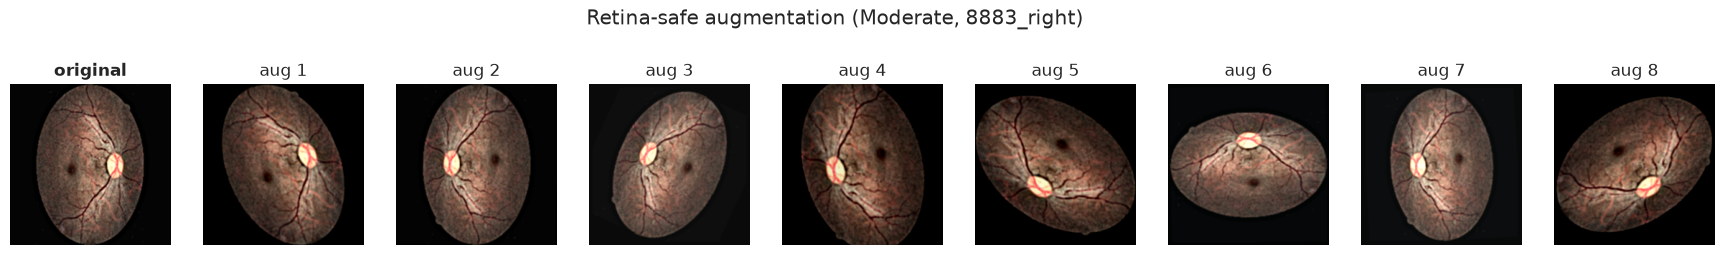

In [2]:
aug = augment.build_augmenter()
sample = train_df[train_df.class_name == "Moderate"].sample(1, random_state=config.SEED).iloc[0]
img = tf.cast(tf.io.decode_png(tf.io.read_file(sample.proc_path), channels=3), tf.float32)
batch = tf.repeat(img[None], 8, axis=0)
views = aug(batch, training=True).numpy().clip(0, 255).astype("uint8")

fig, axes = plt.subplots(1, 9, figsize=(22, 2.8))
axes[0].imshow(img.numpy().astype("uint8")); axes[0].set_title("original", fontweight="bold")
for i, v in enumerate(views, 1):
    axes[i].imshow(v); axes[i].set_title(f"aug {i}")
for a in axes: a.axis("off")
plt.suptitle(f"Retina-safe augmentation ({sample.class_name}, {sample.image_id})", y=1.05)
utils.save_fig("03_augmentations"); plt.show()

## 2. Class imbalance

73 % of training images are `No_DR`; `Proliferate_DR` is 2 %. A model that always says "No DR"
gets 73 % accuracy, so we (a) select checkpoints on **macro-F1**, never accuracy, and
(b) correct the imbalance during training. We combine two standard remedies:

* **partial oversampling** - classes are drawn with probability ∝ √(n_c), so the rarest class is
  repeated ~6x per epoch instead of ~36x (full oversampling would show the same 495 images 36
  times each and overfit them);
* **class-weighted loss** - weights (1/K)/p_c finish the job so every class contributes exactly
  20 % of the loss.

Section 4 ablates this choice against no balancing and weights-only.

,n_images,sampling_prob,images_per_epoch,class_weight,loss_share
class,,,,,
No_DR,18070,0.474,11655,0.422,0.2
Mild,1708,0.146,3583,1.372,0.2
Moderate,3704,0.215,5277,0.932,0.2
Severe,611,0.087,2143,2.294,0.2
Proliferate_DR,495,0.078,1929,2.549,0.2


saved /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/figures/03_class_balance.png


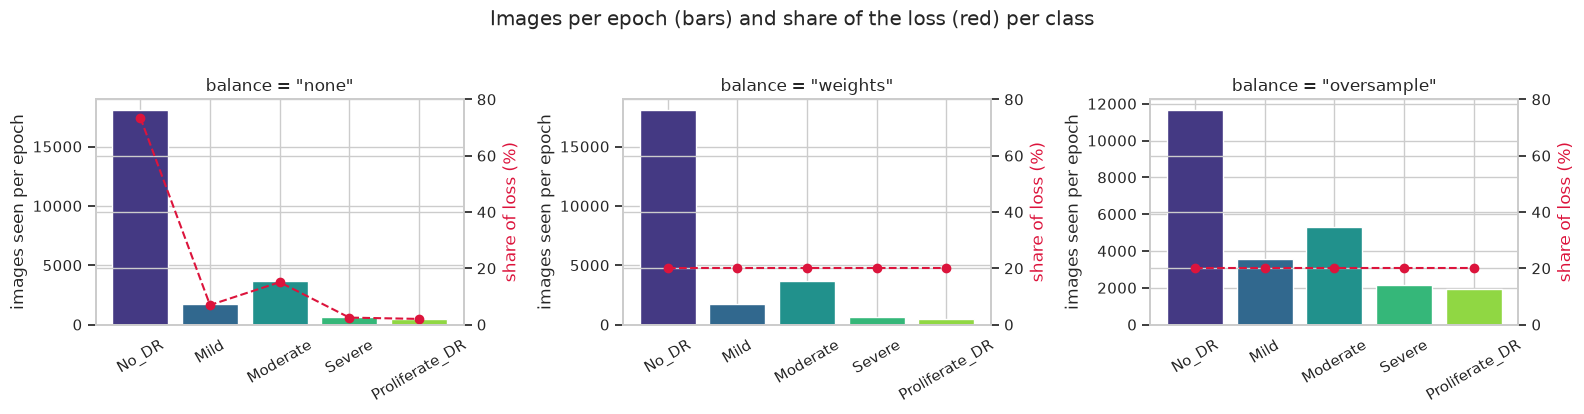

In [3]:
tables = {m: augment.balance_table(train_df, m) for m in augment.BALANCE_MODES}
display(tables["oversample"].round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, (m, t) in zip(axes, tables.items()):
    ax.bar(t.index, t.images_per_epoch, color=sns.color_palette("viridis", 5))
    ax2 = ax.twinx(); ax2.plot(t.index, t.loss_share * 100, "o--", color="crimson"); ax2.set_ylim(0, 80)
    ax2.set_ylabel("share of loss (%)", color="crimson")
    ax.set_title(f'balance = "{m}"'); ax.set_ylabel("images seen per epoch")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Images per epoch (bars) and share of the loss (red) per class", y=1.03)
plt.tight_layout(); utils.save_fig("03_class_balance"); plt.show()

## 3. Baseline: small CNN from scratch

A 4-block VGG-style CNN (1.2 M params) trained from random initialisation. Same data, same
augmentation and balancing as the transfer-learning models, so the only difference is
pre-training.

In [4]:
M.build_baseline_cnn().summary(line_length=90)

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                    │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                 │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b0_conv0 (Conv2D)                     │ (None, 224, 224, 32)         │             864 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b0_bn0 (BatchNormalization)           │ (None, 224, 224, 32)         │             128 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b0_relu0 (Activation)                 │ (None, 224, 224, 32)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b0_conv1 (Conv2D)                     │ (None, 224, 224, 32)         │           9,216 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b0_bn1 (BatchNormalization)           │ (None, 224, 224, 32)         │             128 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b0_relu1 (Activation)                 │ (None, 224, 224, 32)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b0_pool (MaxPooling2D)                │ (None, 112, 112, 32)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b1_conv0 (Conv2D)                     │ (None, 112, 112, 64)         │          18,432 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b1_bn0 (BatchNormalization)           │ (None, 112, 112, 64)         │             256 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b1_relu0 (Activation)                 │ (None, 112, 112, 64)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b1_conv1 (Conv2D)                     │ (None, 112, 112, 64)         │          36,864 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b1_bn1 (BatchNormalization)           │ (None, 112, 112, 64)         │             256 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b1_relu1 (Activation)                 │ (None, 112, 112, 64)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b1_pool (MaxPooling2D)                │ (None, 56, 56, 64)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b2_conv0 (Conv2D)                     │ (None, 56, 56, 128)          │          73,728 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b2_bn0 (BatchNormalization)           │ (None, 56, 56, 128)          │             512 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b2_relu0 (Activation)                 │ (None, 56, 56, 128)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b2_conv1 (Conv2D)                     │ (None, 56, 56, 128)          │         147,456 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ b2_bn1 (BatchNormalization)           │ (None, 56, 56, 128)          │             51

 Total params: 1,176,421 (4.49 MB)

 Trainable params: 1,174,501 (4.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [5]:
res_baseline = T.run_baseline("baseline_cnn", train_df, val_df, epochs=10, lr=1e-3)

Epoch 1/10


/home/nesara/drenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2026-09-20 17:56:42.568429: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] fused(ShuffleDatasetV3:3,RepeatDataset:4): Filling up shuffle buffer (this may take a while): 4450 of 18070


2026-09-20 17:57:02.563703: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] fused(ShuffleDatasetV3:3,RepeatDataset:4): Filling up shuffle buffer (this may take a while): 15668 of 18070


2026-09-20 17:57:06.554676: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


...

767/768 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - acc: 0.4283 - loss: 1.2814 - macro_f1: 0.4190

768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - acc: 0.4285 - loss: 1.2813 - macro_f1: 0.4192


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.


768/768 ━━━━━━━━━━━━━━━━━━━━ 76s 99ms/step - acc: 0.4285 - loss: 1.2813 - macro_f1: 0.4192 - val_acc: 0.2096 - val_loss: 1.3440 - val_macro_f1: 0.2275 - learning_rate: 0.0010


[baseline_cnn] best val macro-F1 0.3367 (epoch 8), acc 0.7147, 14.0 min


## 4. Ablation: does balancing help?

EfficientNet-B0, frozen backbone, head trained for 5 epochs under each balancing mode.
Head-only training is cheap, and it isolates the effect of the sampling/weighting scheme.

In [6]:
ablation = {}
for mode in augment.BALANCE_MODES:
    ablation[mode] = T.run_transfer(f"ablation_balance_{mode}", train_df, val_df,
                                    backbone="EfficientNetB0", balance=mode,
                                    epochs_head=5, epochs_ft=0, verbose=2)
abl = pd.DataFrame(ablation).T[["best_val_f1", "val_acc_at_best", "val_loss_at_best"]]
display(abl)

[ablation_balance_none] stage A: head only, {'params_M': 4.06, 'trainable_M': 0.01}
Epoch 1/5


/home/nesara/drenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2026-09-20 18:10:44.823430: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:47: Filling up shuffle buffer (this may take a while): 4802 of 24588


2026-09-20 18:10:54.828629: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:47: Filling up shuffle buffer (this may take a while): 12040 of 24588


2026-09-20 18:11:04.848155: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:47: Filling up shuffle buffer (this may take a while): 16642 of 24588


...

768/768 - 33s - 43ms/step - acc: 0.3791 - loss: 1.3649 - macro_f1: 0.3726 - val_acc: 0.2407 - val_loss: 1.4965 - val_macro_f1: 0.2218


Epoch 5/5


768/768 - 32s - 42ms/step - acc: 0.3937 - loss: 1.3468 - macro_f1: 0.3829 - val_acc: 0.4911 - val_loss: 1.3364 - val_macro_f1: 0.3011


[ablation_balance_oversample] best val macro-F1 0.3012 (epoch 3), acc 0.5338, 3.6 min


,best_val_f1,val_acc_at_best,val_loss_at_best
none,0.2444,0.7346,0.9952
weights,0.2738,0.4879,1.3529
oversample,0.3012,0.5338,1.3249


saved /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/figures/03_ablation_balance.png


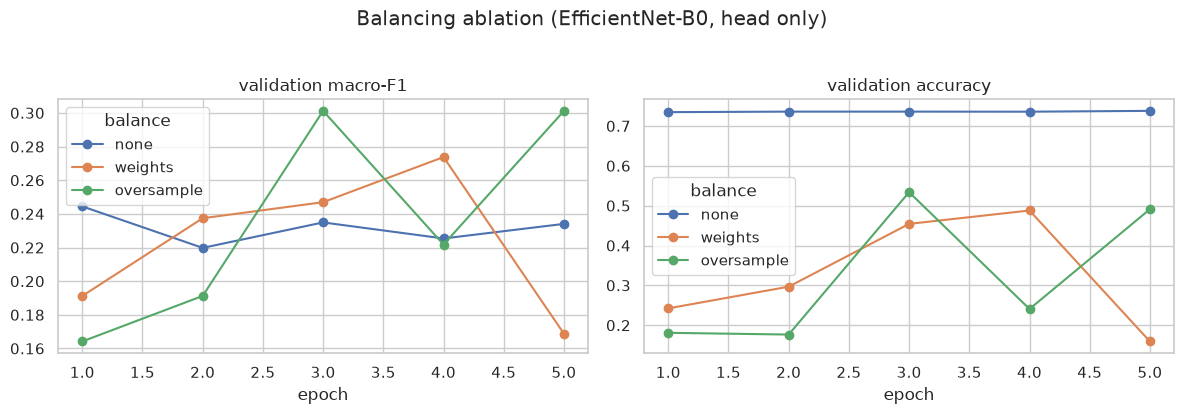

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mode in augment.BALANCE_MODES:
    h = T.load_history(f"ablation_balance_{mode}")
    ep = range(1, len(h["val_macro_f1"]) + 1)
    axes[0].plot(ep, h["val_macro_f1"], "o-", label=mode)
    axes[1].plot(ep, h["val_acc"], "o-", label=mode)
axes[0].set_title("validation macro-F1"); axes[1].set_title("validation accuracy")
for a in axes: a.set_xlabel("epoch"); a.legend(title="balance")
plt.suptitle("Balancing ablation (EfficientNet-B0, head only)", y=1.03)
plt.tight_layout(); utils.save_fig("03_ablation_balance"); plt.show()

## 5. Transfer learning, two stages

* **Stage A** - ImageNet backbone frozen, new head (GAP → Dropout → Dense-5) trained at LR 1e-3.
  Frozen BatchNorm keeps the pretrained statistics intact.
* **Stage B** - top 30 % of backbone layers unfrozen (BatchNorm stays frozen), LR 1e-4,
  `ReduceLROnPlateau` + `EarlyStopping` on val loss, checkpoint on best val macro-F1.

Regularisation: dropout 0.3, AdamW weight decay 1e-4, label smoothing 0.1, augmentation.
We compare EfficientNet-B0 (4 M params) and ResNet50 (24 M params).

In [8]:
M.build_transfer_model("EfficientNetB0").summary(line_length=90)

Model: "EfficientNetB0_dr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                    │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ normalise (ImageNetNormalise)         │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)           │ (None, 7, 7, 1280)           │       4,049,571 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)          │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ probs (Dense)                         │ (None, 5)                    │           6,405 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
res_effb0 = T.run_transfer("effnetb0_ft", train_df, val_df, backbone="EfficientNetB0",
                           epochs_head=5, epochs_ft=20, verbose=2)

[effnetb0_ft] stage A: head only, {'params_M': 4.06, 'trainable_M': 0.01}
Epoch 1/5


/home/nesara/drenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2026-09-20 18:23:25.491287: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] fused(ShuffleDatasetV3:127,RepeatDataset:128): Filling up shuffle buffer (this may take a while): 1847 of 18070


2026-09-20 18:23:45.495888: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] fused(ShuffleDatasetV3:127,RepeatDataset:128): Filling up shuffle buffer (this may take a while): 12248 of 18070


2026-09-20 18:23:55.502431: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] fused(ShuffleDatasetV3:127,RepeatDataset:128): Filling up shuffle buffer (this may take a while): 16150 of 18070


...

Epoch 5/5


768/768 - 34s - 44ms/step - acc: 0.3926 - loss: 1.3518 - macro_f1: 0.3815 - val_acc: 0.3468 - val_loss: 1.4147 - val_macro_f1: 0.2640


[effnetb0_ft] stage B: 57 layers unfrozen, {'params_M': 4.06, 'trainable_M': 3.06}
Epoch 6/25


2026-09-20 18:29:24.946689: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng58{k2=1,k12=2,k13=0,k14=3,k15=1,k17=3,k18=1,k23=0} for conv (f32[192,672,1,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,672,7,7]{3,2,1,0}, f32[32,192,7,7]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0}} is taking a while...
2026-09-20 18:29:25.139319: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.148319454s
Trying algorithm eng58{k2=1,k12=2,k13=0,k14=3,k15=1,k17=3,k18=1,k23=0} for conv (f32[192,672,1,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,672,7,7]{3,2,1,0}, f32[32,192,7,7]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"op

768/768 - 343s - 447ms/step - acc: 0.4158 - loss: 1.3155 - macro_f1: 0.4057 - val_acc: 0.3628 - val_loss: 1.3452 - val_macro_f1: 0.3004 - learning_rate: 1.0000e-04


In [ ]:
res_resnet = T.run_transfer("resnet50_ft", train_df, val_df, backbone="ResNet50",
                            epochs_head=5, epochs_ft=20, verbose=2)

## 6. Hyper-parameter sweep

Head-only runs (5 epochs) on EfficientNet-B0 over learning rate and dropout. Cheap, and the
head LR is the parameter that matters most in stage A. Image size (224) and batch size (32)
are fixed by the preprocessing cache and GPU memory; fine-tune LR 1e-4 follows the usual
"10x lower than the head" rule.

In [ ]:
sweep = {}
for lr in (3e-4, 1e-3, 3e-3):
    for dp in (0.2, 0.5):
        name = f"sweep_lr{lr:g}_dp{dp}"
        sweep[name] = T.run_transfer(name, train_df, val_df, backbone="EfficientNetB0",
                                     lr_head=lr, dropout=dp, epochs_head=5, epochs_ft=0, verbose=0)
sw = pd.DataFrame(sweep).T[["lr_head", "dropout", "best_val_f1", "val_acc_at_best", "val_loss_at_best"]]
display(sw.sort_values("best_val_f1", ascending=False))
piv = sw.pivot(index="lr_head", columns="dropout", values="best_val_f1").astype(float)
plt.figure(figsize=(5, 3.5)); sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis")
plt.title("val macro-F1, head-only (EfficientNet-B0)"); utils.save_fig("03_hparam_sweep"); plt.show()

## 7. All experiments

In [ ]:
exp = T.load_experiments()
cols = ["run", "backbone", "balance", "dropout", "lr_head", "lr_ft", "params_M", "trainable_M",
        "epochs_run", "best_epoch", "best_val_f1", "val_acc_at_best", "val_loss_at_best", "train_min", "sec_per_epoch"]
display(exp[cols].sort_values("best_val_f1", ascending=False).reset_index(drop=True))
exp[cols].to_csv(config.RUN_DIR / "experiments_table.csv", index=False)

In [ ]:
def plot_run(ax_row, name, title):
    h = T.load_history(name); b = h["stage_boundary"]; ep = np.arange(1, len(h["loss"]) + 1)
    for ax, key, lab in zip(ax_row, ("loss", "acc", "macro_f1"), ("loss", "accuracy", "macro-F1")):
        ax.plot(ep, h[key], label="train"); ax.plot(ep, h["val_" + key], label="val")
        if b: ax.axvline(b + 0.5, color="grey", ls="--", lw=1, label="unfreeze")
        ax.set_title(f"{title} - {lab}"); ax.set_xlabel("epoch"); ax.legend()

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
plot_run(axes[0], "baseline_cnn", "Baseline CNN")
plot_run(axes[1], "effnetb0_ft", "EfficientNet-B0")
plot_run(axes[2], "resnet50_ft", "ResNet50")
plt.tight_layout(); utils.save_fig("03_training_curves"); plt.show()

In [ ]:
main = exp[exp.run.isin(["baseline_cnn", "effnetb0_ft", "resnet50_ft"])].set_index("run")
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
main["best_val_f1"].plot.bar(ax=axes[0], color="steelblue", title="best val macro-F1")
main["val_acc_at_best"].plot.bar(ax=axes[1], color="seagreen", title="val accuracy at best epoch")
main["train_min"].plot.bar(ax=axes[2], color="indianred", title="training time (min)")
for a in axes: a.tick_params(axis="x", rotation=0); a.set_xlabel("")
plt.tight_layout(); utils.save_fig("03_backbone_comparison"); plt.show()
best = main["best_val_f1"].idxmax()
print(f"Best model: {best}  ->  outputs/models/{best}.keras  (val macro-F1 {main.loc[best,'best_val_f1']:.4f})")

**Take-aways** (numbers above are regenerated on every run)

* Transfer learning beats the from-scratch CNN by a wide margin at a fraction of the training time.
* Balancing (oversample + weights) lifts macro-F1 substantially; accuracy barely moves - which is
  exactly why accuracy is the wrong metric here.
* Fine-tuning the top blocks (stage B) adds a further gain over the frozen head.
* The best checkpoint by validation macro-F1 is used in `04_evaluate.ipynb` on the untouched test set.